In [5]:
import torchvision
print(torchvision.__version__)

0.19.0


Using device: cuda


100%|██████████| 2640397119/2640397119 [01:19<00:00, 33375420.92it/s]


Extracting ./data/stl10_binary.tar.gz to ./data
Files already downloaded and verified


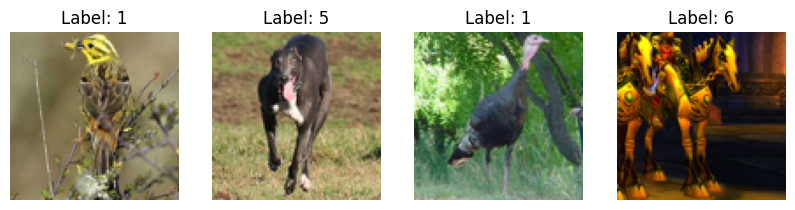

Time taken for Python-based grayscale conversion: 0.4222 seconds


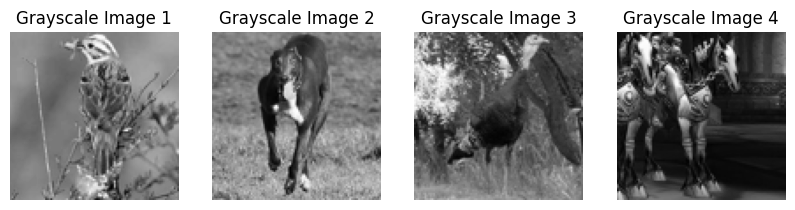

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import STL10
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import time 

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transformations for the STL-10 dataset
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])
train_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.STL10(
    root='./data',
    split='test',
    download=True,
    transform=transform
)
# Load STL-10 dataset
#train_dataset = STL10(root="./storage/dmls/stl10_data", split="train", download=False, transform=transform)
#test_dataset = STL10(root="./storage/dmls/stl10_data", split="test", download=False, transform=transform)

# Select only the first 50 samples from the train dataset
train_dataset_200 = torch.utils.data.Subset(train_dataset, range(200))

# Create DataLoaders
train_loader = DataLoader(train_dataset_200, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Display a few sample images
def show_samples(dataset, num_samples=4):
    plt.figure(figsize=(10, 5))
    for i in range(num_samples):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)  # Change to HxWxC format for display
        image = (image * 0.5 + 0.5).numpy()  # Unnormalize
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.show()

# Display the first 4 samples from the 50 selected samples
show_samples(train_dataset_200, num_samples=4)

# Define the RGB to Grayscale function
def rgb2grey_py(x):
################################################################################################
#WRITE YOUR PYHTON CODE HERER
    r, g, b = image[0, :, :], image[1, :, :], image[2, :, :]
    grey_image = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return grey_image
###############################################################################################

# Convert all images in the first 50 samples to grayscale
grayscale_images = []
start_time_python = time.time()
for i, (image, label) in enumerate(train_dataset_200):
    image = image.to(device)  # Send to the same device as tensor operations
    gray_image = rgb2grey_py(image)
    grayscale_images.append((gray_image, label))

end_time_python = time.time()
python_time = end_time_python - start_time_python
print(f"Time taken for Python-based grayscale conversion: {python_time:.4f} seconds")

# Plot the first 4 grayscale images
plt.figure(figsize=(10, 5))
for i in range(4):
    original_image, label = train_dataset_200[i]
    original_image = original_image.permute(0, 1, 2).cpu().numpy()  # Convert to HxWxC
    original_image = (original_image * 0.5 + 0.5)  # Unnormalize

    gray_image, label = grayscale_images[i]
    gray_image = gray_image.cpu().numpy()

    plt.subplot(1, 4, i + 1)
    plt.imshow(gray_image, cmap="gray")
    plt.title(f"Grayscale Image {i + 1}")
    plt.axis("off")

plt.show()

torch.Size([3, 96, 96])


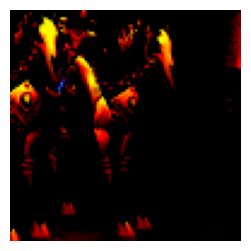

In [8]:
import torchvision.transforms.functional as tvf
original_image, label = train_dataset_200[i]
img = original_image
print(img.shape)
img[:2,:3,:4]
def show_image(x, figsize=(4,3), **kwargs):
    
    plt.figure(figsize=figsize)
    plt.axis("off")
    if len(x.shape)==3: x = x.permute(1, 2, 0)
    plt.imshow(x.cpu(), **kwargs)
    
img = tvf.resize(img, 96, antialias=True)
ch, h, w = img.shape
ch, h, w, h*w

show_image(img)


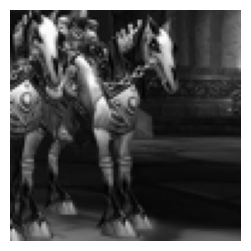

In [9]:

def rgb2grey_simp_py(x):
    c, h, w = x.shape
    n = h * w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    for i in range(n): res[i] = 0.2989 * x[i] + 0.5870 * x[i+n] + 0.1140 * x[2*n+i]
    return res.view(h,w)

img2 = rgb2grey_simp_py(img)
show_image(img2, cmap='gray')

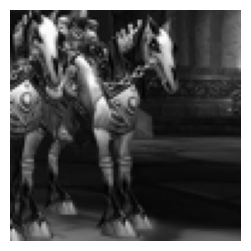

In [11]:
def run_kernel(f, times, *args):
    for i in range(times): f(i, *args)

def extract_gray(i, x, out, n):
    out[i] = 0.2989 * x[i] + 0.5870 * x[i+n] + 0.1140 * x[2*n+i]

def gray_img(x):
    c, h, w = x.shape
    n = h*w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device) 
    run_kernel(extract_gray, h*w, x, res, n)
    return res.view(h,w)

img_g = gray_img(img)
show_image(img_g, cmap='gray')

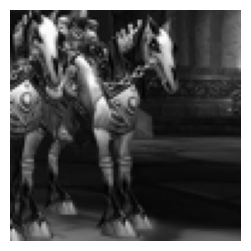

In [14]:
import math
def blk_kernel(f, blocks, threads, *args):
    for i in range(blocks):
                   for j in range(threads): f(i, j, threads, *args)


def rgb2gray_bk(blockidx, threadidx, blockidm, x, out, n):
    i = blockidx * blockidm + threadidx
    if i<n: out[i] = 0.2989 * x[i] + 0.5870 * x[i+n] + 0.1140 * x[2*n+i]


def rgb2gray_pybk(x):
    c, h, w = x.shape
    n = h*w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    threads = 256
    blocks = int(math.ceil(h*w / threads))
    blk_kernel(rgb2gray_bk, blocks, threads, x, res, n)
    return res.view(h,w)

img_g = rgb2gray_pybk(img)
show_image(img_g, cmap='gray')

In [12]:
%pip install -q wurlitzer ninja

Note: you may need to restart the kernel to use updated packages.


In [4]:
%load_ext wurlitzer

The wurlitzer extension is already loaded. To reload it, use:
  %reload_ext wurlitzer


/opt/conda/lib/python3.10/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Using device: cuda
Files already downloaded and verified
Time taken for Python-based grayscale conversion: 0.2177 seconds
3
3
3
3


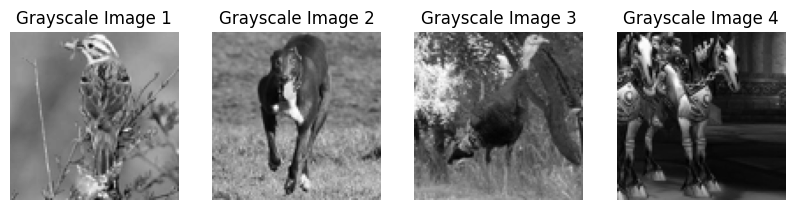

In [15]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import STL10
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io
from torch.utils.cpp_extension import load_inline

# Setting up environment variable
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Function to load CUDA kernel
def load_cuda(cuda_src, cpp_src, funcs, opt=False, verbose=False):
    return load_inline(cuda_sources=[cuda_src], cpp_sources=[cpp_src], functions=funcs,
                       extra_cuda_cflags=["-O3"] if opt else [], verbose=verbose, name="inline_ext")

# CUDA and C++ source code
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}
'''

cuda_src = cuda_begin + r'''
__global__ void rgb2gray_kernel(const unsigned char* x, unsigned char* out, int n, int h, int w) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        int pixel_base = idx;
        out[idx] = static_cast<unsigned char>(
            0.2989f * x[pixel_base] +
            0.5870f * x[pixel_base + n] +
            0.1140f * x[pixel_base + 2 * n]
        );
    }
}

torch::Tensor rgb_to_grayscale(torch::Tensor input) {
    CHECK_INPUT(input);
    int c = input.size(0);
    int h = input.size(1);
    int w = input.size(2);
    int n = h * w; // Total number of pixels

    auto input_flattened = input.flatten(1).contiguous(); 
    auto output = torch::empty({h, w}, torch::dtype(input.dtype()).device(input.device()));

    const int threads = 256;
    const int blocks = (n + threads - 1) / threads;

    rgb2gray_kernel<<<blocks, threads>>>(
        input_flattened.data_ptr<unsigned char>(), 
        output.data_ptr<unsigned char>(), 
        n, h, w
    );

    cudaDeviceSynchronize();

    return output;
}
'''

cpp_src = "torch::Tensor rgb_to_grayscale(torch::Tensor input);"

# Compile and load the CUDA kernel
module = load_cuda(cuda_src, cpp_src, funcs=["rgb_to_grayscale"])

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# STL10 Dataset loading and processing
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])
train_dataset = STL10(root='./data', split='train', download=True, transform=transform)

# Select only the first 50 samples
train_dataset_200 = torch.utils.data.Subset(train_dataset, range(200))

# Convert images to grayscale
grayscale_images = []

start_time_python = time.time()
for i, (image, label) in enumerate(train_dataset_200):
    image = image.to(device)  # Send to the same device as tensor operations
    
    # Un-normalize the image from [-1, 1] to [0, 255]
    image = (image + 1) * 127.5  # Convert from [-1, 1] to [0, 255]
    image = image.clamp(0, 255)  # Ensure values are in the valid range [0, 255]
    
    # Convert to uint8 and move to GPU (for CUDA kernel)
    image_uint8 = image.to(torch.uint8).contiguous().to(device)
    
    # Call the CUDA kernel for grayscale conversion
    gray_image = module.rgb_to_grayscale(image_uint8)  # Pass the uint8 image to the kernel
    
    # Append the grayscale image and label
    grayscale_images.append((gray_image, label))

end_time_python = time.time()
python_time = end_time_python - start_time_python
print(f"Time taken for Python-based grayscale conversion: {python_time:.4f} seconds")

# Plot the first 4 grayscale images
plt.figure(figsize=(10, 5))
for i in range(4):
    original_image, label = train_dataset_200[i]
    print(original_image.dim())
    original_image = original_image.permute(1, 2, 0).cpu().numpy()  # Convert to HxWxC
    original_image = (original_image * 0.5 + 0.5)  # Unnormalize to display the original image

    gray_image, label = grayscale_images[i]
    gray_image = gray_image.cpu().numpy().squeeze()  # Remove the extra channel dimension

    plt.subplot(1, 4, i + 1)
    plt.imshow(gray_image, cmap="gray")
    plt.title(f"Grayscale Image {i + 1}")
    plt.axis("off")

plt.show()
